In [11]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.estimators.estimators import (
    _ExtendedKalmanFilter,
    KalmanXYPhiSpeedGyroEncoder,
    Inertial)

In [12]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
folder_name = "CPSL"
file_name = "CPSL_No_Move"
dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_0",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

found 643 radar samples
found 643 lidar samples
found 643 camera samples
found 643 imu (orientation only) samples
found 643imu (full data) samples
found 643 vehicle velocity samples


In [13]:
history_filter_est = None
history_filter_g = None
history_filter_y = None
history_filter_p = None

#initialize filter history
def history_filters_reset():

    #define globals
    global history_filter_est
    global history_filter_g
    global history_filter_y
    global history_filter_p
    global filter

    history_filter_est = [filter.x.copy()]
    history_filter_g = [0]
    history_filter_y = [np.array([0,0])]
    history_filter_p = [np.sqrt(np.diag(filter.P))]

def history_filters_update_state_history():
    
    #define globals
    global history_filter_est
    global history_filter_p
    global filter

    history_filter_est.append(filter.x.copy())
    history_filter_p.append(np.sqrt(np.diag(filter.P)))
    
def history_filters_update_from_msmt():

    #define globals
    global history_filter_g
    global history_filter_y
    global filter

    history_filter_g.append(filter.g)
    history_filter_y.append(filter.y)

In [14]:
x0 = np.array([
    0.0,
    0.0,
    0.0,
    0,
    0.0, #bias initialized to zero
    0
])

P0 = np.diag([5,5,0.1,0.1,1e-2,1e-2]) #modified to allow for quicker convergence

filter = KalmanXYPhiSpeedGyroEncoder(
    t0=dataset.get_imu_full_data(idx=0)[0,0],
    x0 = x0,
    P0 = P0,
    chi2_pct=0.95, #originally 0.95
    do_chi2=True
)

R = np.diag([1e-2,1e-2,.1]) ** 2
msmt_component = ["x","y","phi"]

filter_last_t = dataset.get_imu_full_data(idx=0)[0,0]
history_filters_reset()

In [15]:
def filters_predict_from_frame_samples(idx = 0):

        #define globals
        global filter_last_t
        global filter
        #core function
        
        imu_data = dataset.get_imu_full_data(idx)
        vel_data = dataset.get_vehicle_vel_data(idx)

        #make sure that the datasets have the same number of samples
        if imu_data.shape[0] != vel_data.shape[0]:
            print("frame {} is bad, (imu: {},data: {})".format(
                idx,imu_data.shape[0],vel_data.shape[0]))
            
            return #skip the frame as it must be bad

        for i in range(imu_data.shape[0]):
            
            #make sure that the time values line up
            assert np.isclose(imu_data[i,0],vel_data[i,0])

            #update time parameters
            dt = imu_data[i,0] - filter_last_t

            #create inertial
            inertial = Inertial(
                gyro=imu_data[i,3],
                sencode=vel_data[i,1]
            )

            #predict the localization filter forward
            filter.predict(
                dt=dt,
                inertial=inertial,
                check_P=False
            )

            #save last time
            filter_last_t = imu_data[i,0]

            #update histories
            history_filters_update_state_history()

        return

def filter_perform_update(
                              estimated_position_m:np.ndarray,
                              estimated_heading_rad:np.ndarray,
                              t:float):
        
        z = np.array([
            estimated_position_m[0],
            estimated_position_m[1],
            estimated_heading_rad
        ])

        filter.update(
            t=t,
            z=z,
            R=R,
            msmt_components=msmt_component
        )

        #save the histories
        history_filters_update_state_history()
        history_filters_update_from_msmt()

In [16]:
#run the filter with zero vel updates

max_frames = 640  #dataset.num_frames

for i in range(max_frames):

    filters_predict_from_frame_samples(idx=i)

    filter_perform_update(
        estimated_heading_rad=0.0,
        estimated_position_m=np.array([0.0,0.0]),
        t = filter_last_t
    )

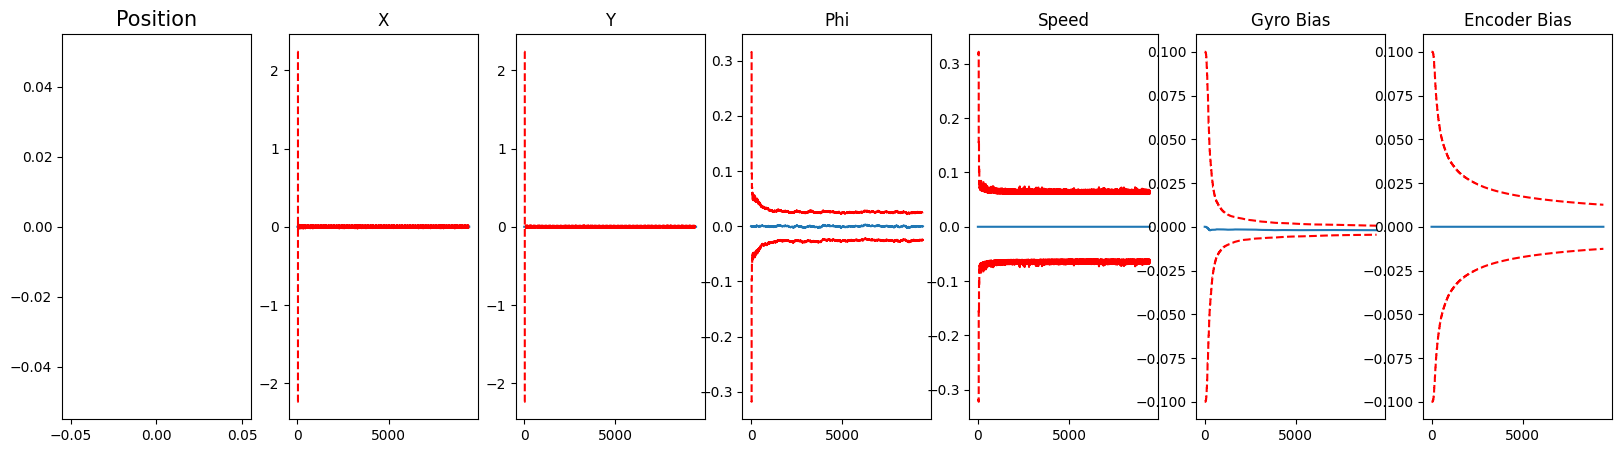

In [17]:
plotter_kalman = PlotterKalman()

plotter_kalman.plot_kalman_result_history(
    x_history=np.array(history_filter_est),
    p_history=np.array(history_filter_p),
    idx=-1
)

0.5729577951308232


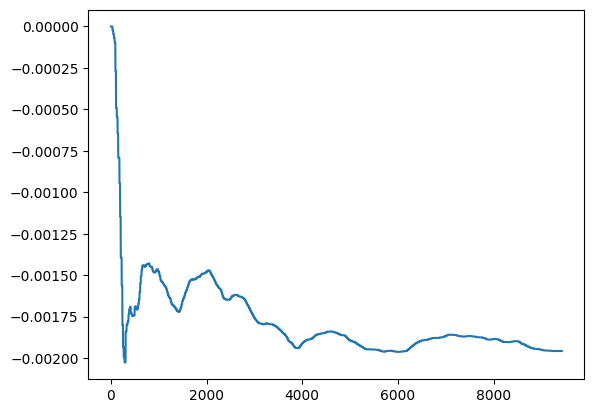

In [18]:
plt.plot(np.array(history_filter_est)[:,4])
print(np.rad2deg(0.01))

In [19]:
#debug the update function
z = np.array([0.0,0.0,0.0])

P_var = np.sqrt(np.diag(filter.P))
print("bias variance: {}".format(P_var[4]))
print("\nP:\n {}".format(filter.P))

H = filter.get_H_matrix(msmt_component)
print("\nH:\n {}".format(H))

y = z - filter.h_func(filter.x,msmt_component)
print("\ny:\n {}".format(y))

# S = H @ filter.P @ H.T
S = H @ filter.P @ H.T + R
Sinv = np.linalg.inv(S)
print("\nS:\n {}".format(S))

K = filter.P @ H.T @ Sinv
print("\nK:\n {}".format(K))



x = filter.x + K @ y
print("\nx:\n {}".format(x))

temp = -1 * (K @ H) @ filter.P
print("\nKHP\n {}".format(temp))


P = (np.eye(filter.P.shape[0]) - K @ H) @ filter.P
print("\nP:\n {}".format(P))



bias variance: 0.0025864915018633545

P:
 [[ 6.69628527e-05  1.33692859e-09  0.00000000e+00  1.69264977e-04
   0.00000000e+00 -2.66499452e-06]
 [ 1.33692859e-09  5.75350414e-05  0.00000000e+00  2.34786187e-08
   0.00000000e+00 -3.69659402e-10]
 [ 0.00000000e+00  0.00000000e+00  6.04933726e-04  0.00000000e+00
  -9.87347966e-06  0.00000000e+00]
 [ 1.69264977e-04  2.34786187e-08  0.00000000e+00  3.63362244e-03
   0.00000000e+00 -5.72096167e-05]
 [ 0.00000000e+00  0.00000000e+00 -9.87347966e-06  0.00000000e+00
   6.68993829e-06  0.00000000e+00]
 [-2.66499452e-06 -3.69659402e-10  0.00000000e+00 -5.72096167e-05
   0.00000000e+00  1.58345902e-04]]

H:
 [[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]

y:
 [0.00000000e+00 0.00000000e+00 1.24851513e-05]

S:
 [[1.66962853e-04 1.33692859e-09 0.00000000e+00]
 [1.33692859e-09 1.57535041e-04 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.06049337e-02]]

K:
 [[ 4.01064378e-01  5.08289554e-06  0.00000000e+00]
 [ 5.08289554e-06  3.652

In [20]:
print("\nP:\n {}".format(filter.P))

temp = filter.P @ H.T
print("\ntemp:\n {}".format(temp))


P:
 [[ 6.69628527e-05  1.33692859e-09  0.00000000e+00  1.69264977e-04
   0.00000000e+00 -2.66499452e-06]
 [ 1.33692859e-09  5.75350414e-05  0.00000000e+00  2.34786187e-08
   0.00000000e+00 -3.69659402e-10]
 [ 0.00000000e+00  0.00000000e+00  6.04933726e-04  0.00000000e+00
  -9.87347966e-06  0.00000000e+00]
 [ 1.69264977e-04  2.34786187e-08  0.00000000e+00  3.63362244e-03
   0.00000000e+00 -5.72096167e-05]
 [ 0.00000000e+00  0.00000000e+00 -9.87347966e-06  0.00000000e+00
   6.68993829e-06  0.00000000e+00]
 [-2.66499452e-06 -3.69659402e-10  0.00000000e+00 -5.72096167e-05
   0.00000000e+00  1.58345902e-04]]

temp:
 [[ 6.69628527e-05  1.33692859e-09  0.00000000e+00]
 [ 1.33692859e-09  5.75350414e-05  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  6.04933726e-04]
 [ 1.69264977e-04  2.34786187e-08  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -9.87347966e-06]
 [-2.66499452e-06 -3.69659402e-10  0.00000000e+00]]
